# Development and Evaluation of a Deep Learning-Based Facial Recognition Model for Security Applications

**Leeds Beckett University | MSc Advanced Computer Science | Dissertation Notebook**

This notebook implements a complete experimental pipeline comparing a custom Baseline CNN against MobileNetV2 transfer learning for facial recognition. Models are trained on Pins Face Recognition and cross-evaluated on LFW using cosine similarity verification.

# 1. Environment Setup

Import all libraries, configure random seeds for reproducibility, and define dataset paths and global hyperparameters.

In [1]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

PINS_DIR          = Path("/kaggle/input/datasets/hereisburak/pins-face-recognition/105_classes_pins_dataset")
LFW_DIR           = Path("/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled")
LFW_MATCH_TEST    = Path("/kaggle/input/datasets/jessicali9530/lfw-dataset/matchpairsDevTest.csv")
LFW_MISMATCH_TEST = Path("/kaggle/input/datasets/jessicali9530/lfw-dataset/mismatchpairsDevTest.csv")

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 105
SEED        = 42

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Image size : {IMG_SIZE}x{IMG_SIZE}")

TensorFlow : 2.20.0
GPU        : True
Image size : 224x224


# 2. Exploratory Data Analysis

Characterise the Pins dataset: class distribution, sample images, and raw image property statistics.

## 2.1 Dataset Overview

Count images per class and compute summary statistics across all 105 celebrity identities.

In [2]:
# Load class directories and image counts
class_dirs = sorted([d for d in PINS_DIR.iterdir() if d.is_dir()])

counts = {
    d.name.replace("pins_", ""): len(
        list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg"))
    )
    for d in class_dirs
}
counts_series = pd.Series(counts).sort_values(ascending=False)

print("Pins Face Recognition: Dataset Summary")
print(f"Total classes        : {len(class_dirs)}")
print(f"Total images         : {counts_series.sum():,}")
print(f"Min images per class : {counts_series.min()}  ({counts_series.idxmin()})")
print(f"Max images per class : {counts_series.max()}  ({counts_series.idxmax()})")
print(f"Mean images          : {counts_series.mean():.1f}")
print(f"Median images        : {counts_series.median():.0f}")

Pins Face Recognition: Dataset Summary
Total classes        : 105
Total images         : 17,534
Min images per class : 86  (Lionel Messi)
Max images per class : 237  (Leonardo DiCaprio)
Mean images          : 167.0
Median images        : 169


## 2.2 Class Distribution Plots

Horizontal bar chart of top 30 classes and a histogram of all 105 class sizes.

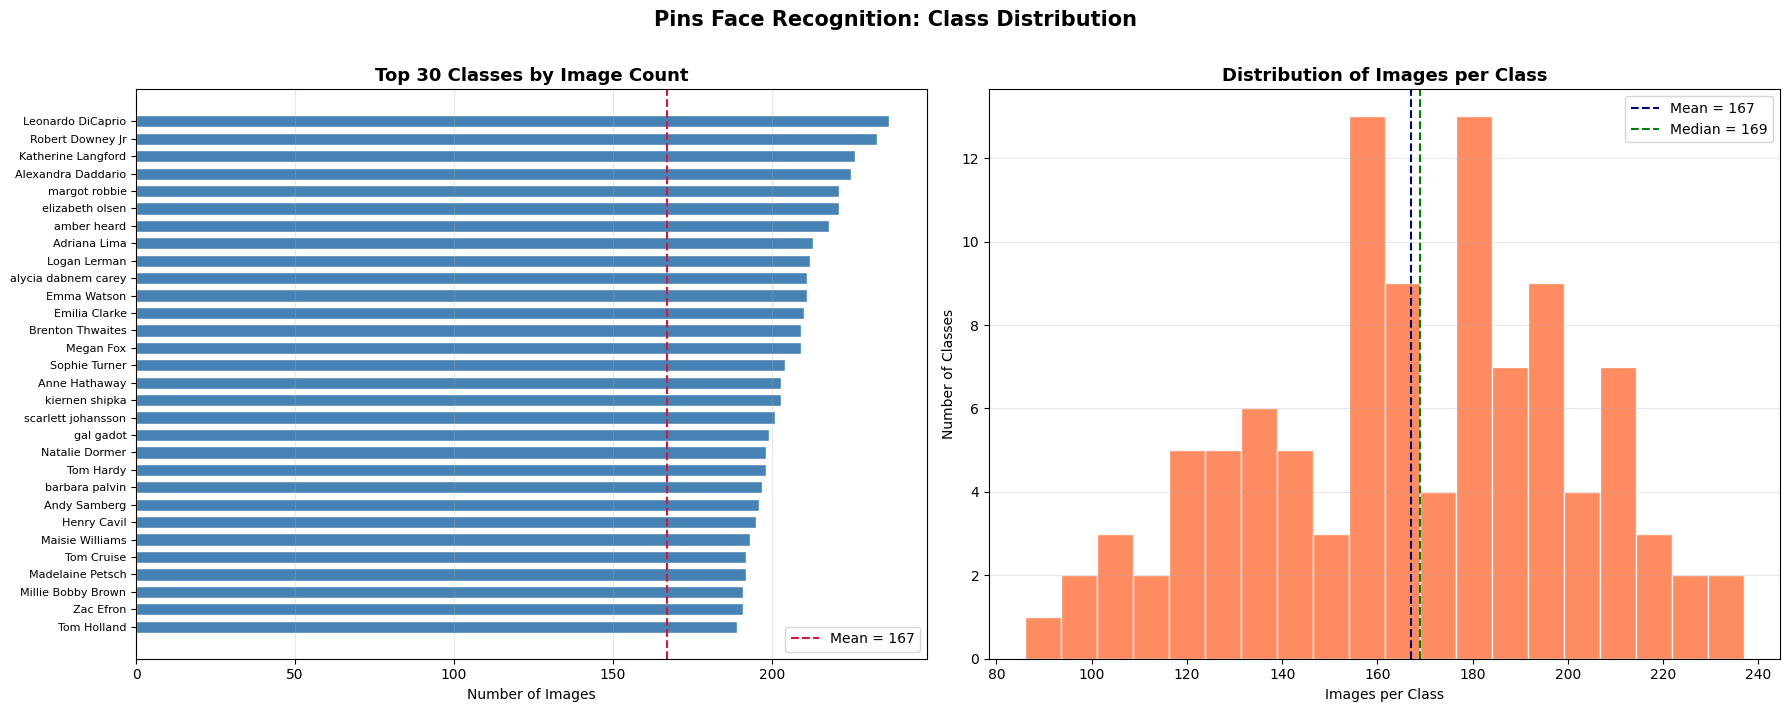

Saved: eda_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Pins Face Recognition: Class Distribution", fontsize=15, fontweight="bold", y=1.01)

# Top 30 classes by image count
top30 = counts_series.head(30)
axes[0].barh(top30.index[::-1], top30.values[::-1], color="steelblue", edgecolor="white", height=0.7)
axes[0].axvline(counts_series.mean(), color="crimson", linestyle="--", lw=1.5,
                label=f"Mean = {counts_series.mean():.0f}")
axes[0].set_title("Top 30 Classes by Image Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Images")
axes[0].tick_params(axis="y", labelsize=8)
axes[0].legend(); axes[0].grid(axis="x", alpha=0.3)

# Histogram of images per class
axes[1].hist(counts_series.values, bins=20, color="coral", edgecolor="white", alpha=0.9)
axes[1].axvline(counts_series.mean(),   color="navy",  linestyle="--", lw=1.5, label=f"Mean = {counts_series.mean():.0f}")
axes[1].axvline(counts_series.median(), color="green", linestyle="--", lw=1.5, label=f"Median = {counts_series.median():.0f}")
axes[1].set_title("Distribution of Images per Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Images per Class"); axes[1].set_ylabel("Number of Classes")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_distribution.png")

## 2.3 Sample Images

Grid of 3 images per class for 12 randomly selected celebrities to inspect pose, lighting and quality variation.

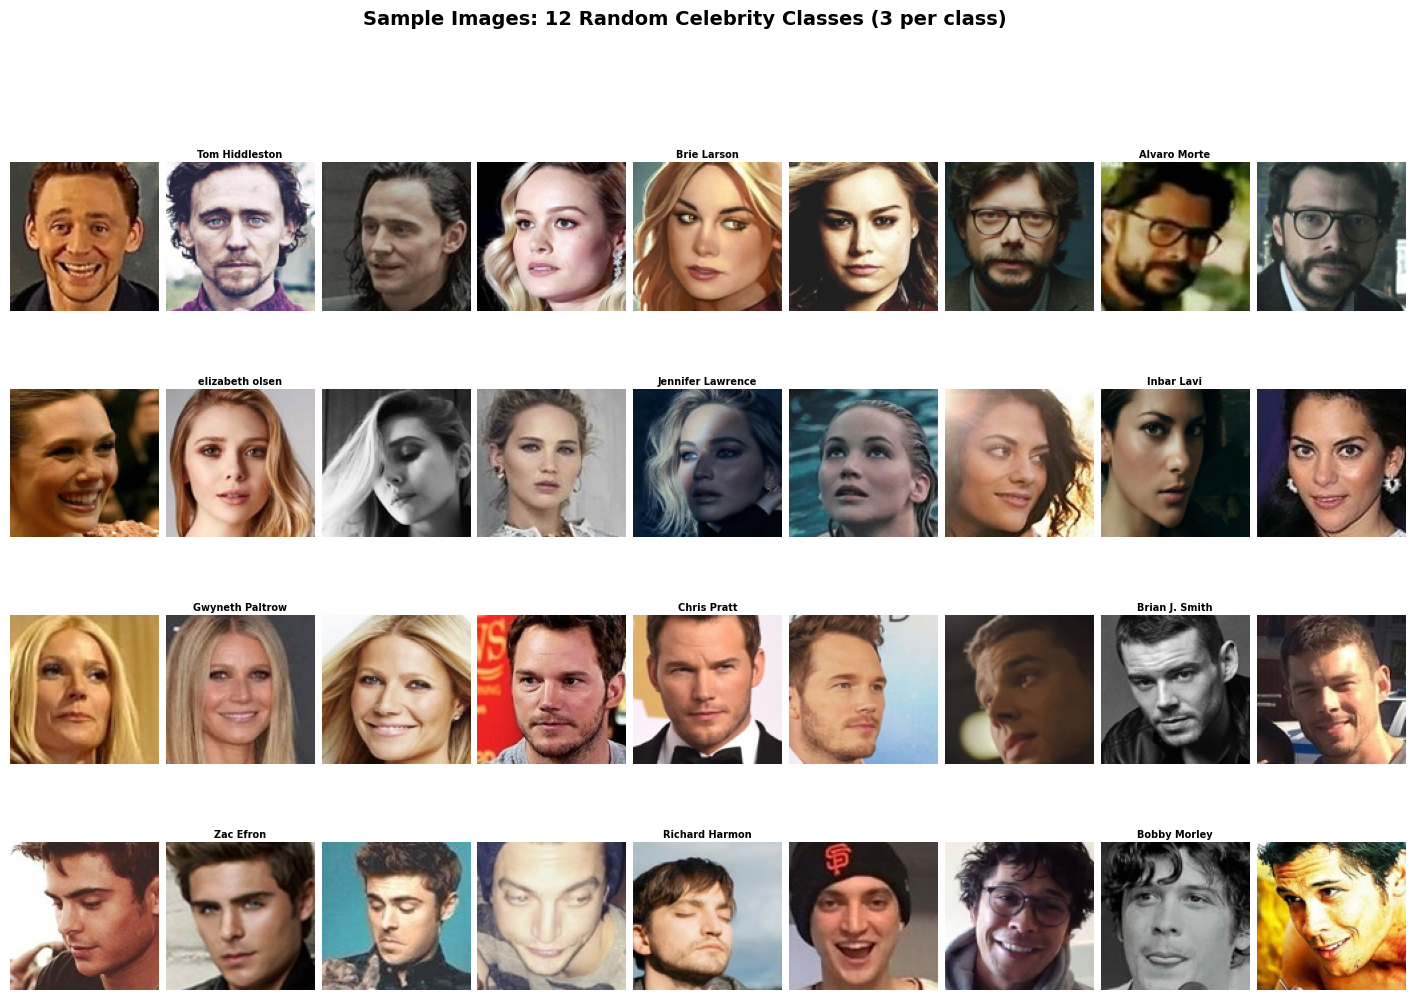

Saved: eda_samples.png


In [4]:
def load_sample_images(class_dir, n=3):
    # Load n random images from a class directory resized to 112x112
    all_imgs = (list(class_dir.glob("*.jpg")) +
                list(class_dir.glob("*.png")) +
                list(class_dir.glob("*.jpeg")))
    selected = random.sample(all_imgs, min(n, len(all_imgs)))
    return [Image.open(p).resize((112, 112)) for p in selected]


fig = plt.figure(figsize=(18, 11))
fig.suptitle("Sample Images: 12 Random Celebrity Classes (3 per class)",
             fontsize=14, fontweight="bold", y=1.01)

sample_classes = random.sample(class_dirs, 12)

for idx, cls_dir in enumerate(sample_classes):
    imgs = load_sample_images(cls_dir, n=3)
    for j, img in enumerate(imgs):
        ax = fig.add_subplot(4, 9, idx * 3 + j + 1)
        ax.imshow(img)
        ax.axis("off")
        if j == 1:
            ax.set_title(cls_dir.name.replace("pins_", ""), fontsize=7, fontweight="bold", pad=3)

plt.subplots_adjust(wspace=0.05, hspace=0.35)
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_samples.png")

## 2.4 Image Property Analysis

Analyse pixel dimensions and channel counts on a 500-image random sample to inform preprocessing decisions.

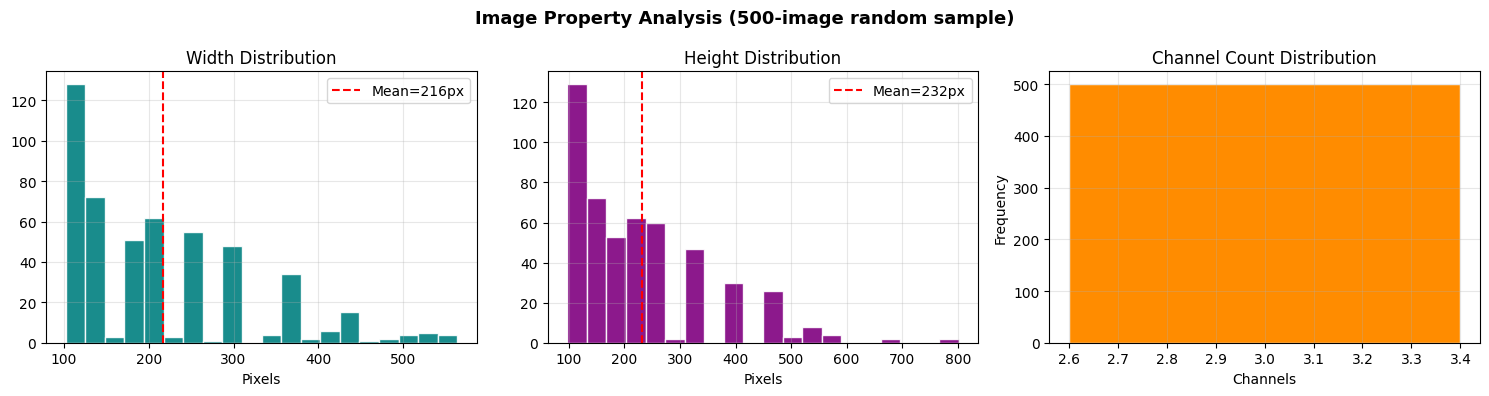

Width  : mean=216px, std=107px
Height : mean=232px, std=121px
Channels: {3: 500}


In [5]:
# Collect all image file paths across all 105 classes
all_images = []
for d in class_dirs:
    all_images.extend(
        list(d.glob("*.jpg")) + list(d.glob("*.jpeg")) + list(d.glob("*.png"))
    )

# Sample 500 images and record dimensions and channel counts
sample_paths = random.sample(all_images, min(500, len(all_images)))
widths, heights, channels_list = [], [], []

for p in sample_paths:
    try:
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        channels_list.append(len(img.getbands()))
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Image Property Analysis (500-image random sample)", fontsize=13, fontweight="bold")

axes[0].hist(widths, bins=20, color="teal", edgecolor="white", alpha=0.9)
axes[0].axvline(np.mean(widths), color="red", linestyle="--", label=f"Mean={np.mean(widths):.0f}px")
axes[0].set_title("Width Distribution"); axes[0].set_xlabel("Pixels"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=20, color="purple", edgecolor="white", alpha=0.9)
axes[1].axvline(np.mean(heights), color="red", linestyle="--", label=f"Mean={np.mean(heights):.0f}px")
axes[1].set_title("Height Distribution"); axes[1].set_xlabel("Pixels"); axes[1].legend(); axes[1].grid(alpha=0.3)

ch_counts = Counter(channels_list)
axes[2].bar(ch_counts.keys(), ch_counts.values(), color="darkorange", edgecolor="white")
axes[2].set_title("Channel Count Distribution"); axes[2].set_xlabel("Channels"); axes[2].set_ylabel("Frequency")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_properties.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Width  : mean={np.mean(widths):.0f}px, std={np.std(widths):.0f}px")
print(f"Height : mean={np.mean(heights):.0f}px, std={np.std(heights):.0f}px")
print(f"Channels: {dict(ch_counts)}")

# 3. Data Preparation

Build training and validation pipelines with augmentation. Six independently controlled augmentation techniques applied to training set only.

## 3.1 Data Pipeline

ImageDataGenerator with 70/30 stratified split. Augmentation on training only; validation receives rescale only.

In [6]:
# Baseline CNN generators — pixel values scaled to [0, 1]
train_datagen = ImageDataGenerator(
    rescale            = 1. / 255,
    validation_split   = 0.30,
    horizontal_flip    = True,
    rotation_range     = 15,
    brightness_range   = [0.7, 1.3],
    zoom_range         = 0.15,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    fill_mode          = 'nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.30)

train_gen = train_datagen.flow_from_directory(
    PINS_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    PINS_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)
class_indices = train_gen.class_indices
idx_to_class  = {v: k for k, v in class_indices.items()}
print(f"Training images   : {len(train_gen) * BATCH_SIZE:,}")
print(f"Validation images : {len(val_gen) * BATCH_SIZE:,}")

Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
Training images   : 12,352
Validation images : 5,216


## 3.2 Augmentation Visualisation

Display the effect of the full augmentation pipeline on a single input image.

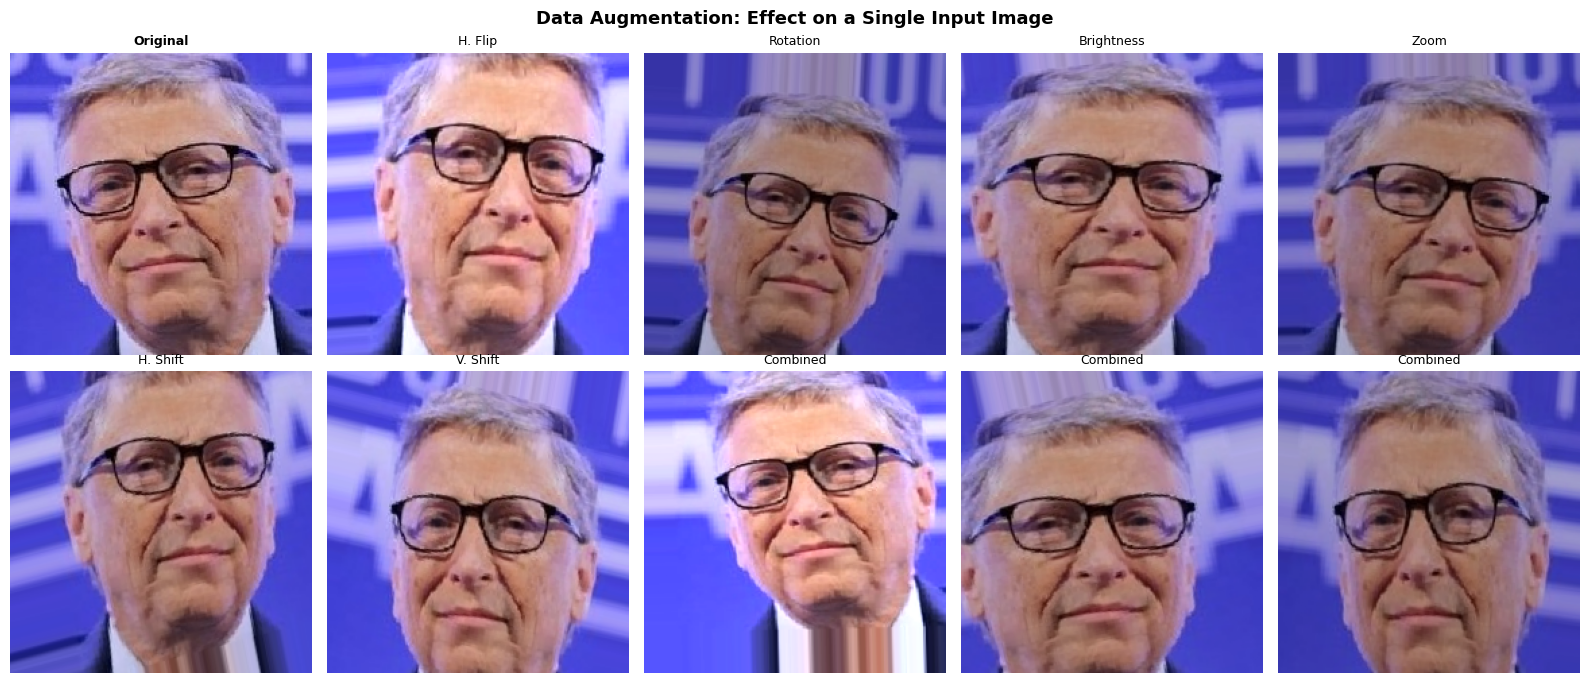

In [7]:
sample_path  = random.choice(all_images)
sample_pil   = tf.keras.utils.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
sample_uint8 = np.expand_dims(tf.keras.utils.img_to_array(sample_pil), axis=0)

aug_viz_gen = ImageDataGenerator(
    horizontal_flip=True, rotation_range=15,
    brightness_range=[0.7, 1.3], zoom_range=0.15,
    width_shift_range=0.10, height_shift_range=0.10, fill_mode='nearest'
)
aug_iter   = aug_viz_gen.flow(sample_uint8, batch_size=1)
aug_labels = ["H. Flip","Rotation","Brightness","Zoom",
              "H. Shift","V. Shift","Combined","Combined","Combined"]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Data Augmentation: Effect on a Single Input Image", fontsize=13, fontweight="bold")
axes[0,0].imshow(sample_uint8[0].astype(np.uint8))
axes[0,0].set_title("Original", fontsize=9, fontweight="bold"); axes[0,0].axis("off")
for ax, lbl in zip(axes.flatten()[1:], aug_labels):
    ax.imshow(np.clip(next(aug_iter)[0] / 255.0, 0, 1))
    ax.set_title(lbl, fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches="tight"); plt.show()

# 4. Model Architectures

Define the Baseline CNN (trained from scratch) and MobileNetV2 (ImageNet transfer learning).

## 4.1 Baseline Custom CNN

Four convolutional blocks (32, 64, 128, 256 filters) with batch normalisation, max pooling, and dropout. GAP feeds a 512-unit dense head. Total: 771,593 parameters.

In [8]:
def build_baseline_cnn(num_classes=NUM_CLASSES, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential(name="Baseline_CNN")
    model.add(layers.Input(shape=input_shape))

    # Block 1: 32 filters
    model.add(layers.Conv2D(32,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32,(3,3),padding="same",activation="relu"))
    model.add(layers.MaxPooling2D(2,2)); model.add(layers.Dropout(0.25))

    # Block 2: 64 filters
    model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu"))
    model.add(layers.MaxPooling2D(2,2)); model.add(layers.Dropout(0.25))

    # Block 3: 128 filters
    model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
    model.add(layers.MaxPooling2D(2,2)); model.add(layers.Dropout(0.35))

    # Block 4: 256 filters
    model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D()); model.add(layers.Dropout(0.50))

    # Classification head
    model.add(layers.Dense(512,activation="relu"))
    model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.50))
    model.add(layers.Dense(num_classes,activation="softmax"))
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)
baseline_model.summary()
print(f"\nTotal parameters: {baseline_model.count_params():,}")

I0000 00:00:1784961505.196385      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784961505.199290      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             

 Total params: 771,593 (2.94 MB)

 Trainable params: 769,609 (2.94 MB)

 Non-trainable params: 1,984 (7.75 KB)


Total parameters: 771,593


## 4.2 MobileNetV2 Architecture

MobileNetV2 pretrained on ImageNet with a custom classification head. Phase 1 freezes the base; Phase 2 unfreezes all 154 layers. Total: 2,969,769 parameters.

In [9]:
base_model = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights="imagenet")
base_model.trainable = False
inp = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x   = base_model(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(512,activation="relu")(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES,activation="softmax")(x)
tl_model = models.Model(inputs=inp, outputs=out, name="MobileNetV2_TL")
tl_model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
tl_model.summary()
print(f"\nTotal parameters: {tl_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 105)            │        53,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,969,769 (11.33 MB)

 Trainable params: 710,761 (2.71 MB)

 Non-trainable params: 2,259,008 (8.62 MB)


Total parameters: 2,969,769


# 5. Model Training

Train both architectures. MobileNetV2 uses a three-phase strategy: head-only, full unfreeze with cosine decay, and extended fine-tuning with label smoothing.

## 5.1 Train Baseline CNN

Cosine decay schedule from 1e-3 over 30 epochs with label smoothing 0.05. EarlyStopping monitors validation accuracy with patience 8.

In [10]:
baseline_model = build_baseline_cnn()

# Cosine decay from 1e-3 provides smooth LR annealing across 30 epochs
total_steps_base = len(train_gen) * 30
lr_base = optimizers.schedules.CosineDecay(
    initial_learning_rate = 1e-3,
    decay_steps           = total_steps_base,
    alpha                 = 1e-6
)

# Label smoothing 0.05 regularises the output distribution
# and prevents overconfidence on limited per-class samples
baseline_model.compile(
    optimizer = optimizers.Adam(learning_rate=lr_base),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics   = ["accuracy"]
)

baseline_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_baseline.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

print("Training Baseline CNN...")
h_base = baseline_model.fit(
    train_gen,
    epochs          = 30,
    validation_data = val_gen,
    callbacks       = baseline_callbacks,
    verbose         = 1
)
print("Baseline CNN training complete.")

Training Baseline CNN...
Epoch 1/30


2026-07-25 06:38:41.099532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:38:41.253894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:38:44.125725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:38:44.418020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/386 ━━━━━━━━━━━━━━━━━━━━ 2:38:19 25s/step - accuracy: 0.0312 - loss: 6.0736

I0000 00:00:1784961534.211535     147 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 78/386 ━━━━━━━━━━━━━━━━━━━━ 3:10 617ms/step - accuracy: 0.0167 - loss: 5.9069

2026-07-25 06:39:44.575887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:39:44.722902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:39:45.007770: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:39:45.150672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 06:39:46.069005: E external/local_xla/xla/stream_

386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.0158 - loss: 5.6363
Epoch 1: val_accuracy improved from None to 0.01152, saving model to best_baseline.keras

Epoch 1: finished saving model to best_baseline.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 338s 813ms/step - accuracy: 0.0158 - loss: 5.4570 - val_accuracy: 0.0115 - val_loss: 4.8868
Epoch 2/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.0173 - loss: 5.1562
Epoch 2: val_accuracy improved from 0.01152 to 0.01248, saving model to best_baseline.keras

Epoch 2: finished saving model to best_baseline.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 179s 462ms/step - accuracy: 0.0153 - loss: 5.1373 - val_accuracy: 0.0125 - val_loss: 5.8079
Epoch 3/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.0172 - loss: 5.0227
Epoch 3: val_accuracy improved from 0.01248 to 0.02189, saving model to best_baseline.keras

Epoch 3: finished saving model to best_baseline.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 177s 459ms/step - accuracy: 0.0170 - l

## 5.2 MobileNetV2 Data Generators

MobileNetV2 requires inputs scaled to [-1, 1] as per its ImageNet training normalisation. Dedicated generators are built separately from the baseline CNN pipeline.

In [11]:
# MobileNetV2 specific generators with preprocess_input scaling inputs to [-1, 1]
# This matches the normalisation used during ImageNet pretraining
mn_train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split       = 0.30,
    horizontal_flip        = True,
    rotation_range         = 15,
    brightness_range       = [0.7, 1.3],
    zoom_range             = 0.15,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10,
    fill_mode              = 'nearest'
)
mn_val_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split       = 0.30
)

mn_train_gen = mn_train_datagen.flow_from_directory(
    PINS_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)
mn_val_gen = mn_val_datagen.flow_from_directory(
    PINS_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)
print(f"MobileNetV2 train : {len(mn_train_gen) * BATCH_SIZE:,}")
print(f"MobileNetV2 val   : {len(mn_val_gen) * BATCH_SIZE:,}")

Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
MobileNetV2 train : 12,352
MobileNetV2 val   : 5,216


## 5.3 MobileNetV2 Phase 1: Frozen Base

Train classification head only for 10 epochs. Base layers frozen to preserve ImageNet representations.

In [12]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_model(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(512, activation="relu")(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
tl_model = models.Model(inputs=inp, outputs=out, name="MobileNetV2_TL")
tl_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

p1_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_mobilenet_p1.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

print("MobileNetV2 Phase 1: training classification head...")
h_p1 = tl_model.fit(
    mn_train_gen,
    epochs          = 10,
    validation_data = mn_val_gen,
    callbacks       = p1_callbacks,
    verbose         = 1
)
print("Phase 1 complete.")

MobileNetV2 Phase 1: training classification head...
Epoch 1/10


2026-07-25 08:13:34.228640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 08:13:34.366542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


331/386 ━━━━━━━━━━━━━━━━━━━━ 24s 437ms/step - accuracy: 0.0598 - loss: 4.6535

2026-07-25 08:16:11.354547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 08:16:11.493768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 08:16:11.631023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.0646 - loss: 4.5814

2026-07-25 08:17:03.922733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 08:17:04.060098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.16935, saving model to best_mobilenet_p1.keras

Epoch 1: finished saving model to best_mobilenet_p1.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 229s 545ms/step - accuracy: 0.0970 - loss: 4.1106 - val_accuracy: 0.1694 - val_loss: 3.5187
Epoch 2/10
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.1953 - loss: 3.3143
Epoch 2: val_accuracy improved from 0.16935 to 0.22427, saving model to best_mobilenet_p1.keras

Epoch 2: finished saving model to best_mobilenet_p1.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 184s 477ms/step - accuracy: 0.2066 - loss: 3.2648 - val_accuracy: 0.2243 - val_loss: 3.1914
Epoch 3/10
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2559 - loss: 3.0063
Epoch 3: val_accuracy improved from 0.22427 to 0.24808, saving model to best_mobilenet_p1.keras

Epoch 3: finished saving model to best_mobilenet_p1.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 181s 468ms/step - accuracy: 0.2542 - loss: 3.0085 - val_accuracy: 0.2481 - val_loss: 3.064

## 5.4 MobileNetV2 Phase 2: Full Unfreeze, Cosine Decay LR

Unfreeze all 154 base layers. Cosine decay from 5e-5 over 50 epochs, patience 12.

In [13]:
base_model.trainable = True

# 50 epochs total with higher starting LR for deeper feature adaptation
total_steps_p2 = len(mn_train_gen) * 50
lr_cosine_p2 = optimizers.schedules.CosineDecay(
    initial_learning_rate = 5e-5,
    decay_steps           = total_steps_p2,
    alpha                 = 1e-7
)
tl_model.compile(
    optimizer = optimizers.Adam(learning_rate=lr_cosine_p2),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

print(f"Unfrozen layers     : {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}")

p2_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=12,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_mobilenet_p2.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

print("\nMobileNetV2 Phase 2: full fine-tuning...")
h_p2 = tl_model.fit(
    mn_train_gen,
    epochs          = 50,
    validation_data = mn_val_gen,
    callbacks       = p2_callbacks,
    verbose         = 1
)
print("Phase 2 complete.")

Unfrozen layers     : 154
Trainable parameters: 2,934,633

MobileNetV2 Phase 2: full fine-tuning...
Epoch 1/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.1349 - loss: 3.8606
Epoch 1: val_accuracy improved from None to 0.21141, saving model to best_mobilenet_p2.keras

Epoch 1: finished saving model to best_mobilenet_p2.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 280s 582ms/step - accuracy: 0.1795 - loss: 3.4585 - val_accuracy: 0.2114 - val_loss: 3.7834
Epoch 2/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.3097 - loss: 2.6975
Epoch 2: val_accuracy improved from 0.21141 to 0.30703, saving model to best_mobilenet_p2.keras

Epoch 2: finished saving model to best_mobilenet_p2.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 184s 476ms/step - accuracy: 0.3372 - loss: 2.5848 - val_accuracy: 0.3070 - val_loss: 2.8594
Epoch 3/50
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.4220 - loss: 2.1868
Epoch 3: val_accuracy improved from 0.30703 to 0.37423, saving model to best_mobilenet_

## 5.5 MobileNetV2 Extended Fine-Tuning: Label Smoothing

Label smoothing 0.1 with cosine decay from 3e-6 over 30 epochs, patience 10.

In [14]:
total_steps_ext = len(mn_train_gen) * 30
lr_cosine_ext = optimizers.schedules.CosineDecay(
    initial_learning_rate = 3e-6,
    decay_steps           = total_steps_ext,
    alpha                 = 1e-8
)
tl_model.compile(
    optimizer = optimizers.Adam(learning_rate=lr_cosine_ext),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ["accuracy"]
)

ext_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_mobilenet_final.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

print("MobileNetV2 extended fine-tuning with label smoothing 0.1...")
h_ext = tl_model.fit(
    mn_train_gen,
    epochs          = 30,
    validation_data = mn_val_gen,
    callbacks       = ext_callbacks,
    verbose         = 1
)
print("Extended fine-tuning complete.")

MobileNetV2 extended fine-tuning with label smoothing 0.1...
Epoch 1/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9890 - loss: 1.3643
Epoch 1: val_accuracy improved from None to 0.83391, saving model to best_mobilenet_final.keras

Epoch 1: finished saving model to best_mobilenet_final.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 264s 564ms/step - accuracy: 0.9875 - loss: 1.3377 - val_accuracy: 0.8339 - val_loss: 1.6837
Epoch 2/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9837 - loss: 1.2875
Epoch 2: val_accuracy did not improve from 0.83391
386/386 ━━━━━━━━━━━━━━━━━━━━ 190s 492ms/step - accuracy: 0.9817 - loss: 1.2823 - val_accuracy: 0.8289 - val_loss: 1.6704
Epoch 3/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9807 - loss: 1.2658
Epoch 3: val_accuracy did not improve from 0.83391
386/386 ━━━━━━━━━━━━━━━━━━━━ 182s 472ms/step - accuracy: 0.9799 - loss: 1.2636 - val_accuracy: 0.8214 - val_loss: 1.6573
Epoch 4/30
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/ste

## 5.6 Training History

Accuracy and loss curves for both models. MobileNetV2 shows all three phases merged into a single curve with phase boundary markers.

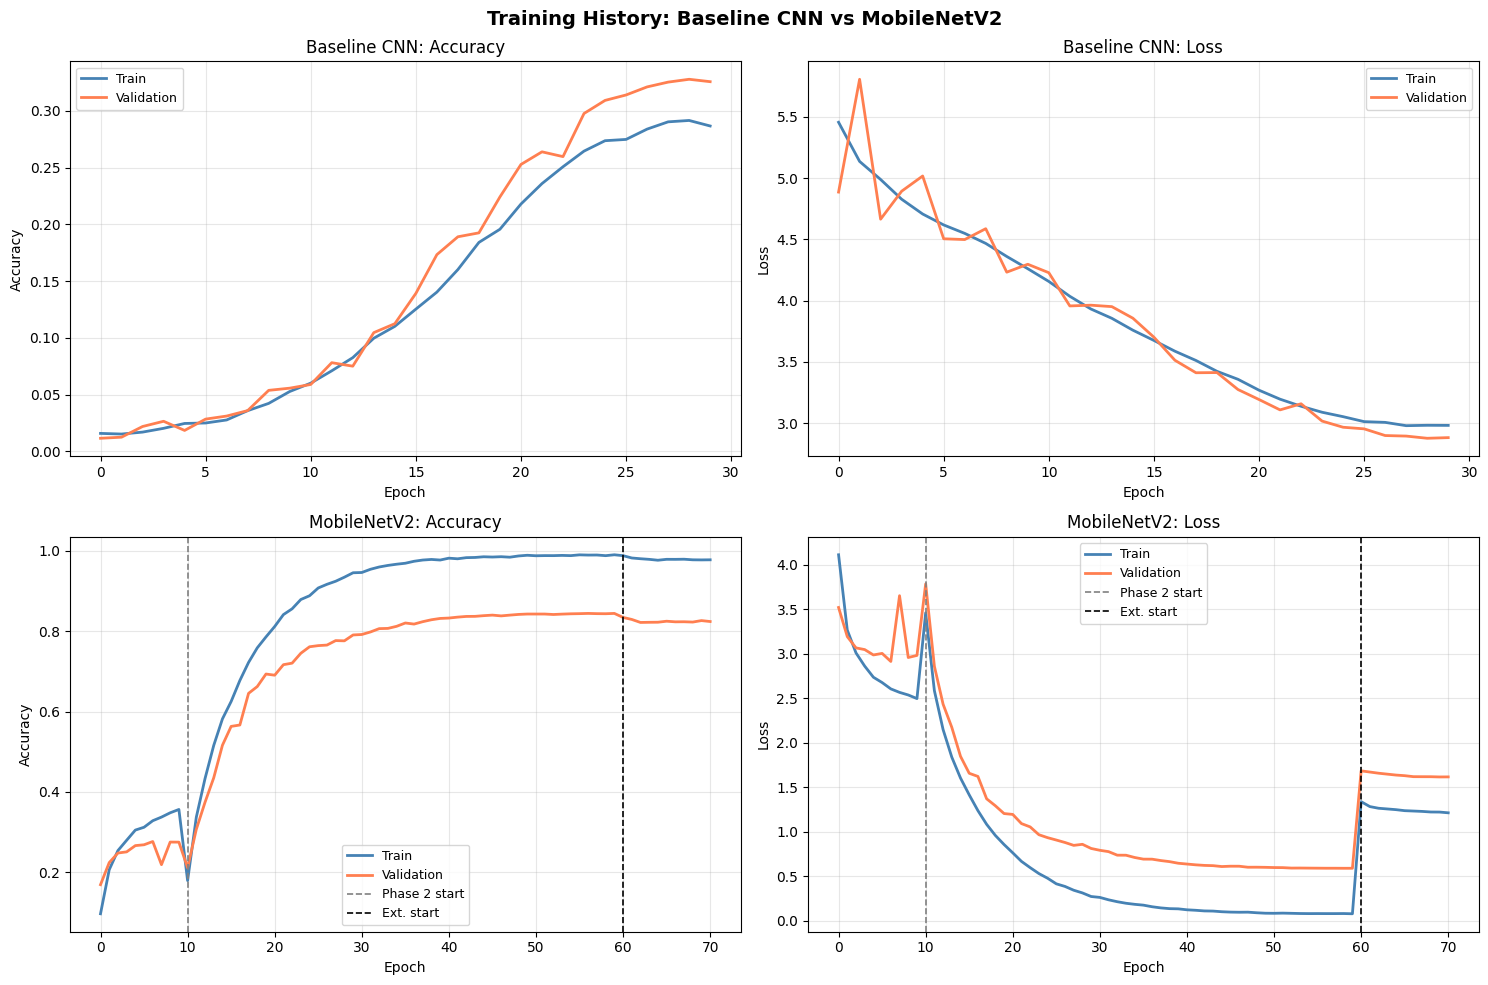

Saved: training_history.png


In [18]:
def merge_histories(*history_objects):
    # Concatenate multiple Keras History objects into a single dict
    merged = {}
    for k in history_objects[0].history.keys():
        merged[k] = []
        for h in history_objects:
            merged[k] += h.history[k]
    return merged


tl_merged = merge_histories(h_p1, h_p2, h_ext)

# Phase boundary epoch indices for MobileNetV2
p1_end = len(h_p1.history["accuracy"])
p2_end = p1_end + len(h_p2.history["accuracy"])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Training History: Baseline CNN vs MobileNetV2", fontsize=14, fontweight="bold")

histories = [
    (h_base.history, "Baseline CNN",  None),
    (tl_merged,      "MobileNetV2",   (p1_end, p2_end))
]

for i, (hist, name, markers) in enumerate(histories):

    # Accuracy plot
    axes[i, 0].plot(hist["accuracy"],     color="steelblue", lw=2, label="Train")
    axes[i, 0].plot(hist["val_accuracy"], color="coral",     lw=2, label="Validation")
    if markers:
        axes[i, 0].axvline(markers[0], color="gray",  linestyle="--", lw=1.2, label="Phase 2 start")
        axes[i, 0].axvline(markers[1], color="black", linestyle="--", lw=1.2, label="Ext. start")
    axes[i, 0].set_title(f"{name}: Accuracy", fontsize=12)
    axes[i, 0].set_xlabel("Epoch"); axes[i, 0].set_ylabel("Accuracy")
    axes[i, 0].legend(fontsize=9); axes[i, 0].grid(alpha=0.3)

    # Loss plot
    axes[i, 1].plot(hist["loss"],     color="steelblue", lw=2, label="Train")
    axes[i, 1].plot(hist["val_loss"], color="coral",     lw=2, label="Validation")
    if markers:
        axes[i, 1].axvline(markers[0], color="gray",  linestyle="--", lw=1.2, label="Phase 2 start")
        axes[i, 1].axvline(markers[1], color="black", linestyle="--", lw=1.2, label="Ext. start")
    axes[i, 1].set_title(f"{name}: Loss", fontsize=12)
    axes[i, 1].set_xlabel("Epoch"); axes[i, 1].set_ylabel("Loss")
    axes[i, 1].legend(fontsize=9); axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_history.png")

# 6. Evaluation: Pins Validation Set

Comprehensive evaluation using accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and full per-class classification reports.

## 6.1 Classification Metrics

Weighted accuracy, precision, recall, and F1-score for both models on the held-out validation set.

In [19]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"  {model_name}")
    print(f"{'_'*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    return y_true, y_pred, y_prob, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1
    }

# Baseline CNN evaluated with rescale [0,1] generator
y_true_b, y_pred_b, y_prob_b, metrics_b = evaluate_model(
    baseline_model, val_gen, "Baseline CNN"
)

# MobileNetV2 evaluated with preprocess_input [-1,1] generator
y_true_t, y_pred_t, y_prob_t, metrics_t = evaluate_model(
    tl_model, mn_val_gen, "MobileNetV2 Full Fine-Tune"
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step
  Baseline CNN
____________________________________________________
  Accuracy  : 0.3280  (32.80%)
  Precision : 0.3318
  Recall    : 0.3280
  F1-Score  : 0.3065
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step
  MobileNetV2 Full Fine-Tune
____________________________________________________
  Accuracy  : 0.8339  (83.39%)
  Precision : 0.8414
  Recall    : 0.8339
  F1-Score  : 0.8347


## 6.2 Confusion Matrix

Normalised confusion matrices for the top 20 most frequent classes. Values show proportion of true-class samples predicted into each class.

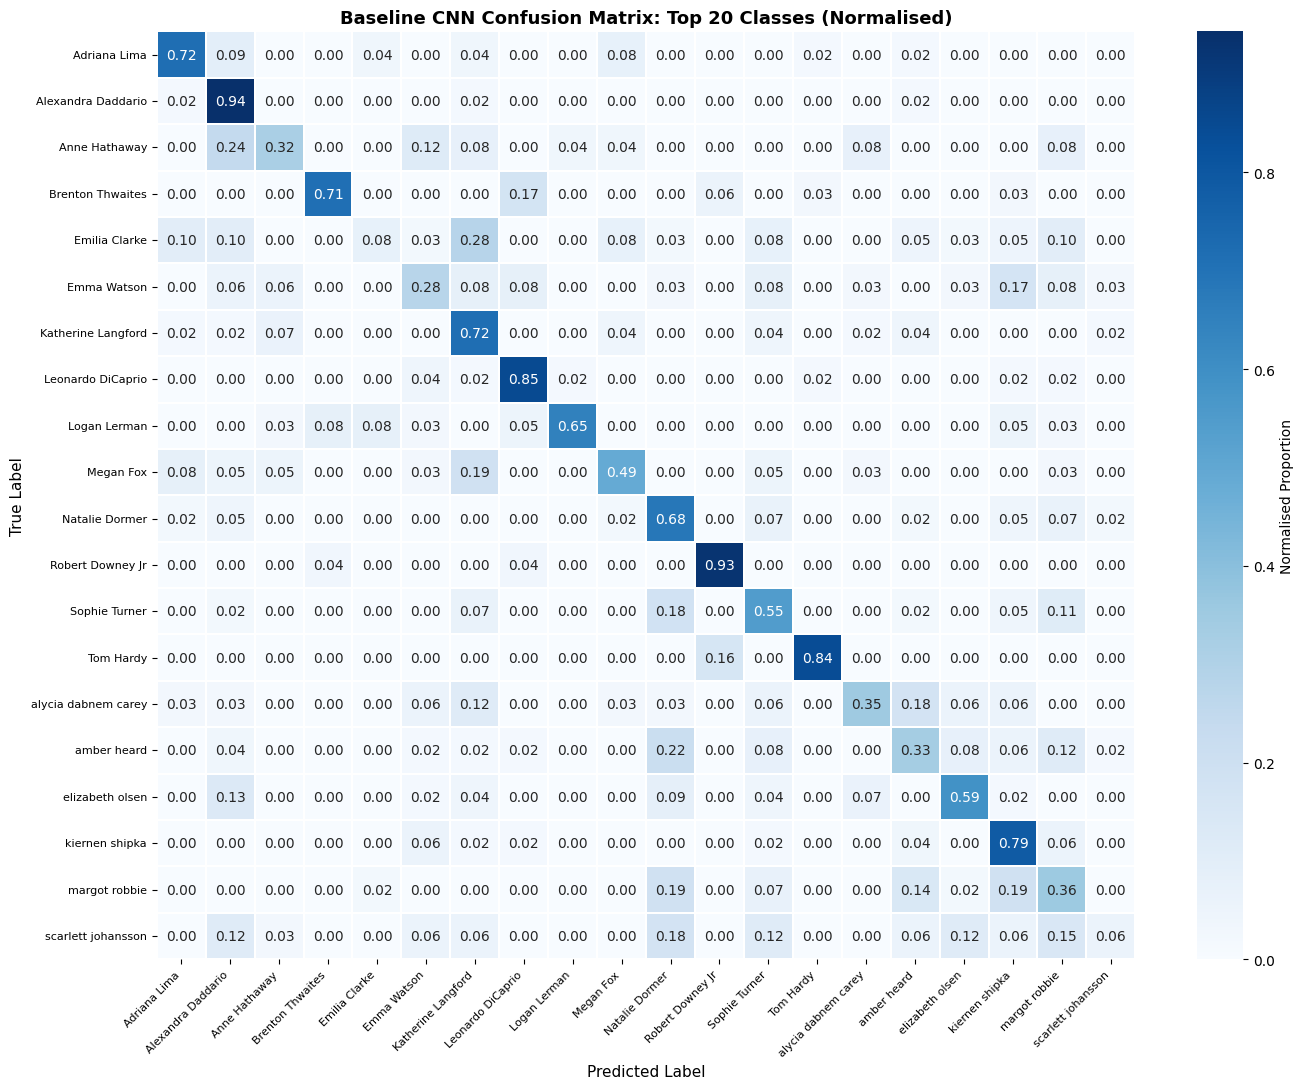

Saved: baseline_cnn_confusion_matrix.png


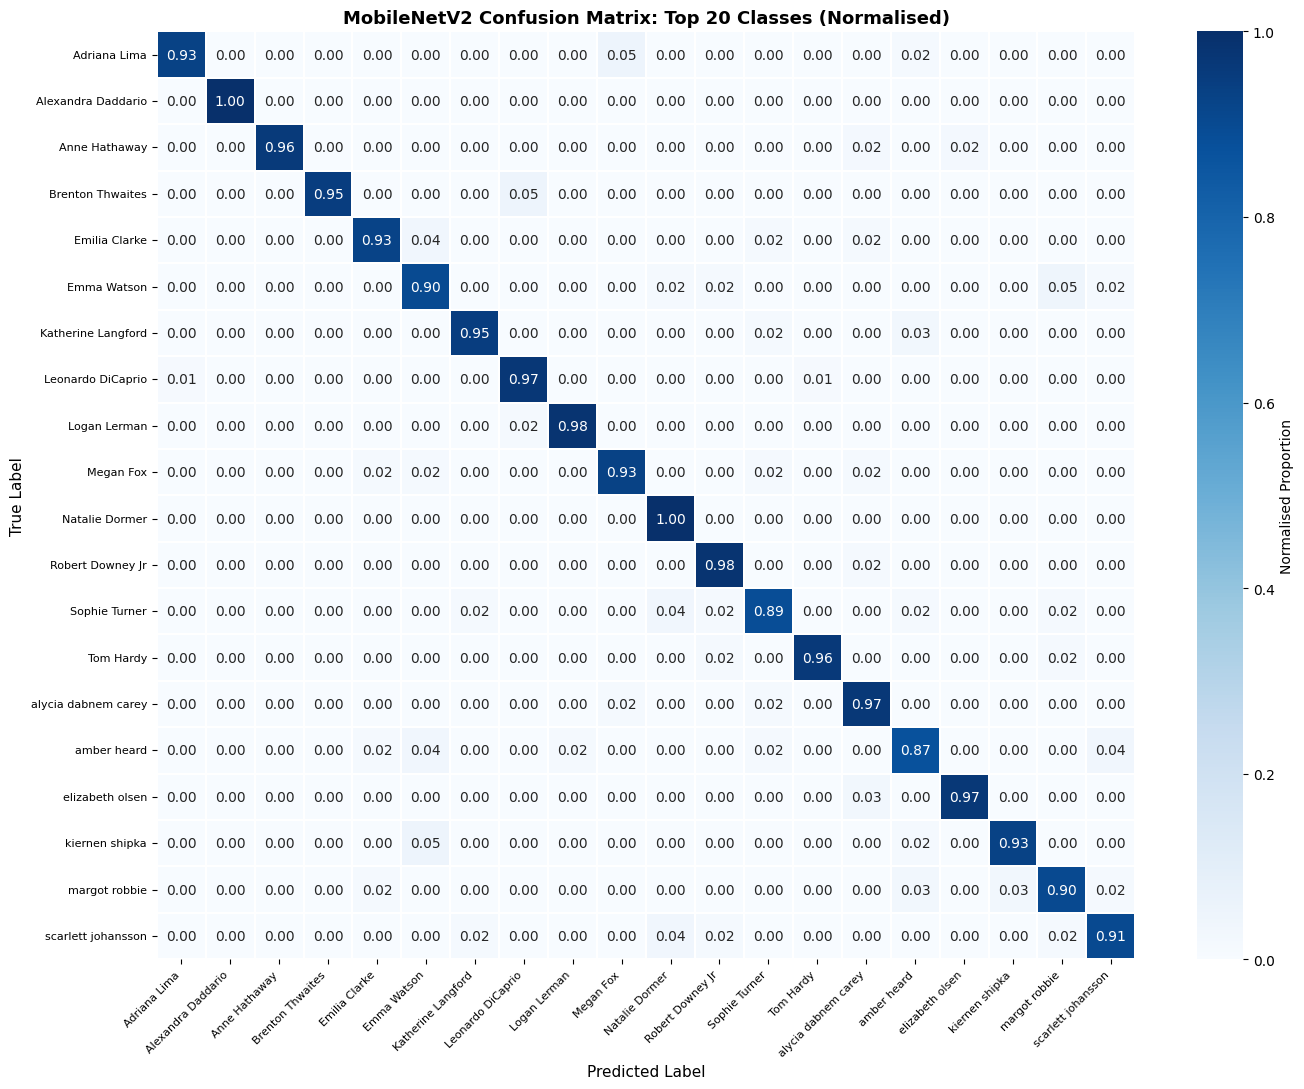

Saved: mobilenetv2_confusion_matrix.png


In [20]:
def plot_confusion_matrix(y_true, y_pred, idx_to_class, n=20, title="Confusion Matrix"):
    top_classes = [c for c, _ in Counter(y_true).most_common(n)]
    mask = np.isin(y_true, top_classes)
    yt, yp = y_true[mask], y_pred[mask]
    sorted_top = sorted(top_classes)
    labels = [idx_to_class[c].replace("pins_", "") for c in sorted_top]
    cm      = confusion_matrix(yt, yp, labels=sorted_top)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.3, cbar_kws={"label": "Normalised Proportion"})
    ax.set_title(f"{title}: Top {n} Classes (Normalised)", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=11); ax.set_xlabel("Predicted Label", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {fname}")

plot_confusion_matrix(y_true_b, y_pred_b, idx_to_class, 20, "Baseline CNN Confusion Matrix")
plot_confusion_matrix(y_true_t, y_pred_t, idx_to_class, 20, "MobileNetV2 Confusion Matrix")

## 6.3 ROC Curves and AUC

Per-class ROC curves and macro-average AUC for the 10 most frequent identity classes.

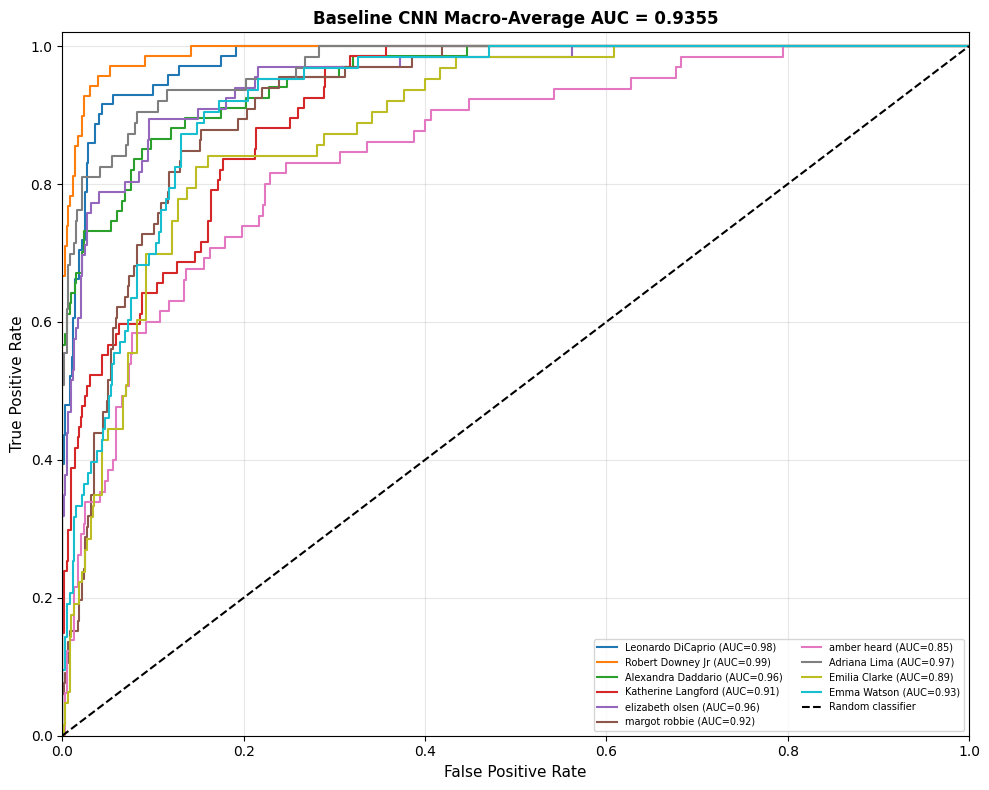

Saved: baseline_cnn_roc.png  |  Macro AUC = 0.9355


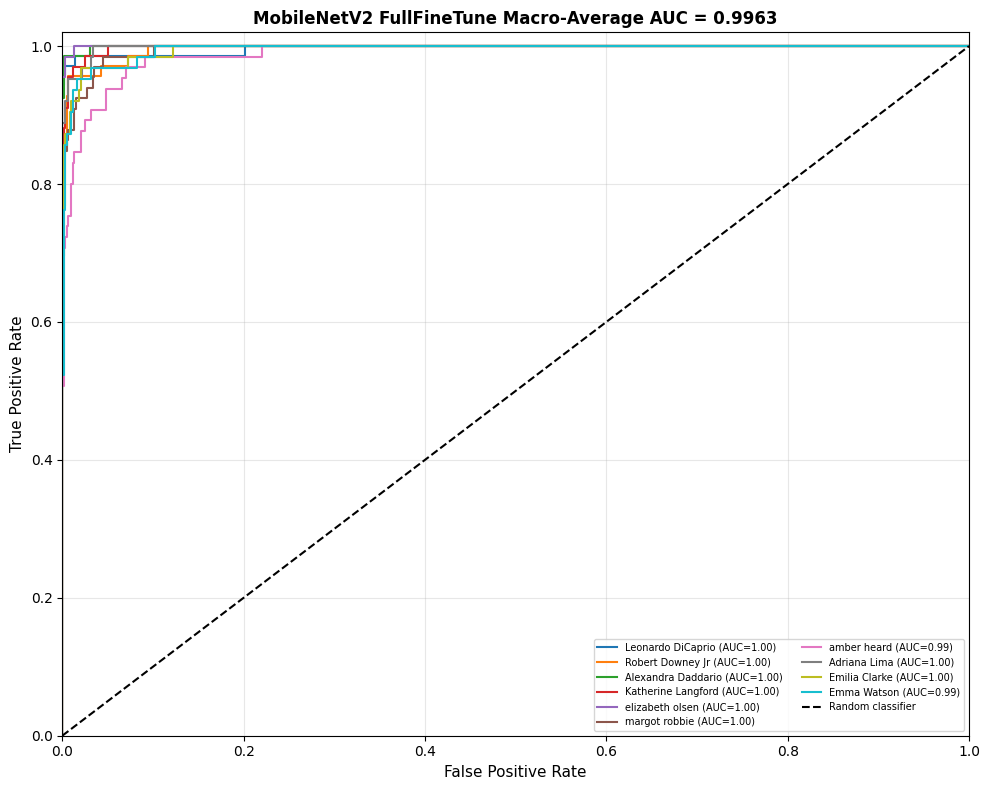

Saved: mobilenetv2_fullfinetune_roc.png  |  Macro AUC = 0.9963


In [21]:
def plot_roc_curves(y_true, y_prob, idx_to_class, n=10, title="ROC"):
    # Per-class ROC and macro AUC for top n classes
    top_classes = [c for c, _ in Counter(y_true).most_common(n)]
    mask    = np.isin(y_true, top_classes)
    yt      = y_true[mask]
    yp      = y_prob[mask][:, top_classes]
    yt_bin  = label_binarize(yt, classes=top_classes)
    colors  = plt.cm.tab10(np.linspace(0, 1, n))
    aucs    = []

    fig, ax = plt.subplots(figsize=(10, 8))

    for i, cls_idx in enumerate(top_classes):
        fpr, tpr, _ = roc_curve(yt_bin[:, i], yp[:, i])
        roc_auc = auc(fpr, tpr); aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[i], lw=1.5,
                label=f"{idx_to_class[cls_idx].replace('pins_','')} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=11); ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(f"{title} Macro-Average AUC = {np.mean(aucs):.4f}", fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + "_roc.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {fname}  |  Macro AUC = {np.mean(aucs):.4f}")


plot_roc_curves(y_true_b, y_prob_b, idx_to_class, 10, "Baseline CNN")
plot_roc_curves(y_true_t, y_prob_t, idx_to_class, 10, "MobileNetV2 FullFineTune")

## 6.4 Per-Class Classification Report: All 105 Classes

Full precision, recall, and F1 for every identity class. Saved to CSV for the dissertation appendix.

In [22]:
target_names = [idx_to_class[i].replace("pins_", "") for i in range(NUM_CLASSES)]

print("Baseline CNN: Per-Class Classification Report")
print("_" * 70)
report_b = classification_report(y_true_b, y_pred_b, target_names=target_names, zero_division=0)
print(report_b)

print("MobileNetV2: Per-Class Classification Report")
print("_" * 70)
report_t = classification_report(y_true_t, y_pred_t, target_names=target_names, zero_division=0)
print(report_t)

# Build per-class DataFrame for both models
rows = []
for class_idx, class_name in enumerate(target_names):
    for model_name, y_true, y_pred in [("Baseline CNN", y_true_b, y_pred_b),
                                        ("MobileNetV2",  y_true_t, y_pred_t)]:
        mask = y_true == class_idx
        if mask.sum() > 0:
            rows.append({
                "Model"    : model_name,
                "Class"    : class_name,
                "Precision": round(precision_score(y_true==class_idx, y_pred==class_idx, zero_division=0), 4),
                "Recall"   : round(recall_score(y_true==class_idx, y_pred==class_idx, zero_division=0), 4),
                "F1"       : round(f1_score(y_true==class_idx, y_pred==class_idx, zero_division=0), 4),
                "Support"  : int(mask.sum())
            })

per_class_df = pd.DataFrame(rows)
per_class_df.to_csv("per_class_report.csv", index=False)
print("Saved: per_class_report.csv")

Baseline CNN: Per-Class Classification Report
______________________________________________________________________
                        precision    recall  f1-score   support

          Adriana Lima       0.29      0.60      0.40        63
          Alex Lawther       0.47      0.40      0.43        45
    Alexandra Daddario       0.36      0.75      0.49        67
          Alvaro Morte       0.64      0.56      0.60        41
           Amanda Crew       0.44      0.51      0.47        35
          Andy Samberg       0.66      0.43      0.52        58
         Anne Hathaway       0.20      0.13      0.16        60
        Anthony Mackie       0.71      0.54      0.62        37
         Avril Lavigne       0.27      0.60      0.37        48
           Ben Affleck       0.50      0.16      0.24        37
            Bill Gates       0.75      0.50      0.60        36
          Bobby Morley       0.47      0.34      0.39        41
      Brenton Thwaites       0.42      0.40      0

## 6.5 Model Comparison Chart

Side-by-side grouped bar chart of all four metrics for both models.

Pins Validation: Model Comparison
       Model  Accuracy  Precision  Recall  F1-Score
Baseline CNN    0.3280     0.3318  0.3280    0.3065
 MobileNetV2    0.8339     0.8414  0.8339    0.8347


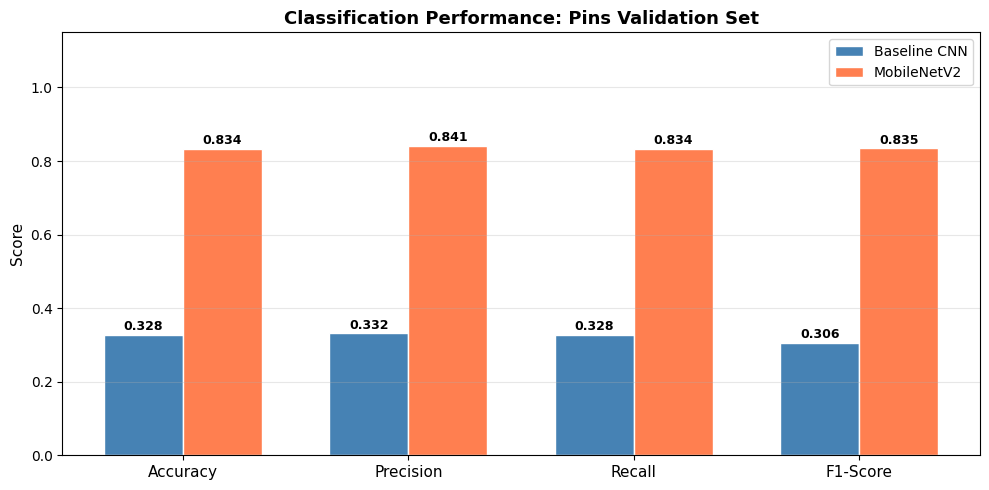

Saved: model_comparison.png


In [23]:
comparison_df = pd.DataFrame({
    "Model"    : ["Baseline CNN", "MobileNetV2"],
    "Accuracy" : [metrics_b["accuracy"],  metrics_t["accuracy"]],
    "Precision": [metrics_b["precision"], metrics_t["precision"]],
    "Recall"   : [metrics_b["recall"],    metrics_t["recall"]],
    "F1-Score" : [metrics_b["f1"],        metrics_t["f1"]]
}).round(4)

print("Pins Validation: Model Comparison")
print(comparison_df.to_string(index=False))

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metric_names)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_b = ax.bar(x - w/2, comparison_df.iloc[0][metric_names].values, w,
                label="Baseline CNN", color="steelblue", edgecolor="white")
bars_t = ax.bar(x + w/2, comparison_df.iloc[1][metric_names].values, w,
                label="MobileNetV2",  color="coral",     edgecolor="white")

for bar in list(bars_b) + list(bars_t):
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012),
                ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Classification Performance: Pins Validation Set", fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

# 7. Cross-Dataset Verification: LFW

Evaluate both models on LFW using cosine similarity between 512-dimensional embeddings. Youden's J statistic determines the optimal threshold. FMR and FNMR are reported as security-relevant metrics.

## 7.1 Load LFW Verification Pairs

500 matched pairs (same identity, label=1) and 500 mismatched pairs (different identities, label=0) from the official LFW split files.

In [24]:
def load_lfw_pairs(lfw_base, match_csv, mismatch_csv):
    # Load official LFW matched and mismatched verification pairs
    pairs = []

    match_df = pd.read_csv(match_csv)
    for _, row in match_df.iterrows():
        name = row.iloc[0]
        p1 = lfw_base / name / f"{name}_{int(row.iloc[1]):04d}.jpg"
        p2 = lfw_base / name / f"{name}_{int(row.iloc[2]):04d}.jpg"
        if p1.exists() and p2.exists():
            pairs.append((str(p1), str(p2), 1))   # 1 = same person

    mismatch_df = pd.read_csv(mismatch_csv)
    for _, row in mismatch_df.iterrows():
        n1, n2 = row.iloc[0], row.iloc[2]
        p1 = lfw_base / n1 / f"{n1}_{int(row.iloc[1]):04d}.jpg"
        p2 = lfw_base / n2 / f"{n2}_{int(row.iloc[3]):04d}.jpg"
        if p1.exists() and p2.exists():
            pairs.append((str(p1), str(p2), 0))   # 0 = different people

    return pairs


lfw_pairs = load_lfw_pairs(LFW_DIR, LFW_MATCH_TEST, LFW_MISMATCH_TEST)

matched    = sum(1 for _, _, l in lfw_pairs if l == 1)
mismatched = sum(1 for _, _, l in lfw_pairs if l == 0)

print(f"LFW pairs loaded:")
print(f"  Total      : {len(lfw_pairs)}")
print(f"  Matched    : {matched}   (same identity)")
print(f"  Mismatched : {mismatched}  (different identities)")

LFW pairs loaded:
  Total      : 1000
  Matched    : 500   (same identity)
  Mismatched : 500  (different identities)


## 7.2 Feature Extraction and Cosine Similarity Verification

Keras 3 compatible extractor supports both Sequential and Functional models. Optimal threshold via Youden's J. FMR and FNMR computed at that threshold.

In [25]:
def get_feature_extractor(model):
    # Keras 3 compatible — Sequential vs Functional requires different approaches
    if isinstance(model, models.Sequential):
        # Sequential: rebuild without final softmax layer
        inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
        x   = inp
        for layer in model.layers[:-1]:
            x = layer(x)
        return tf.keras.Model(inputs=inp, outputs=x, name=f"{model.name}_extractor")
    else:
        # Functional (MobileNetV2): tap the last Dense layer before softmax
        embedding_layer = next(
            l for l in reversed(model.layers)
            if isinstance(l, layers.Dense) and l != model.layers[-1]
        )
        return tf.keras.Model(inputs=model.input, outputs=embedding_layer.output,
                              name=f"{model.name}_extractor")


def preprocess_single(img_path):
    # Load and normalise a single image for inference
    try:
        img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        arr = tf.keras.utils.img_to_array(img) / 255.0
        return np.expand_dims(arr, axis=0).astype(np.float32)
    except Exception:
        return None


def cosine_similarity_score(emb_a, emb_b):
    # Cosine similarity between two embedding vectors
    a = emb_a.flatten(); b = emb_b.flatten()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def evaluate_lfw_verification(model, pairs, model_name):
    extractor = get_feature_extractor(model)
    # Warmup call to initialise the graph before timed inference
    _ = extractor(np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), training=False)

    similarities, labels = [], []
    print(f"Computing embeddings: {model_name}  ({len(pairs)} pairs)")

    for i, (p1, p2, label) in enumerate(pairs):
        img1 = preprocess_single(p1)
        img2 = preprocess_single(p2)
        if img1 is None or img2 is None:
            continue
        emb1 = extractor(img1, training=False).numpy()
        emb2 = extractor(img2, training=False).numpy()
        similarities.append(cosine_similarity_score(emb1, emb2))
        labels.append(label)
        if (i + 1) % 250 == 0:
            print(f"  {i+1}/{len(pairs)} pairs processed...")

    sims = np.array(similarities)
    labs = np.array(labels)

    # ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(labs, sims)
    roc_auc    = auc(fpr, tpr)

    # Optimal threshold via Youden's J statistic (maximise TPR - FPR)
    opt_thresh = thresholds[np.argmax(tpr - fpr)]
    preds      = (sims >= opt_thresh).astype(int)

    # Standard verification metrics
    acc  = accuracy_score(labs, preds)
    prec = precision_score(labs, preds, zero_division=0)
    rec  = recall_score(labs, preds, zero_division=0)
    f1   = f1_score(labs, preds, zero_division=0)

    # Security metrics: FMR and FNMR at optimal threshold
    tn, fp, fn, tp = confusion_matrix(labs, preds).ravel()
    fmr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0   # False Match Rate
    fnmr = fn / (fn + tp) if (fn + tp) > 0 else 0.0   # False Non-Match Rate

    print(f"  {model_name}: LFW Verification")
    print(f"{'_'*52}")
    print(f"  Pairs evaluated  : {len(labs)}")
    print(f"  AUC-ROC          : {roc_auc:.4f}")
    print(f"  Threshold (Youden's J): {opt_thresh:.4f}")
    print(f"  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision        : {prec:.4f}")
    print(f"  Recall           : {rec:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  FMR              : {fmr:.4f}  (False Match Rate)")
    print(f"  FNMR             : {fnmr:.4f}  (False Non-Match Rate)")

    return {
        "fpr": fpr, "tpr": tpr, "auc": roc_auc,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "fmr": fmr, "fnmr": fnmr,
        "similarities": sims, "labels": labs, "threshold": opt_thresh
    }


lfw_b = evaluate_lfw_verification(baseline_model, lfw_pairs, "Baseline CNN")
lfw_t = evaluate_lfw_verification(tl_model,       lfw_pairs, "MobileNetV2 Full Fine-Tune")

Computing embeddings: Baseline CNN  (1000 pairs)
  250/1000 pairs processed...
  500/1000 pairs processed...
  750/1000 pairs processed...
  1000/1000 pairs processed...
  Baseline CNN: LFW Verification
____________________________________________________
  Pairs evaluated  : 1000
  AUC-ROC          : 0.7251
  Threshold (Youden's J): 0.4814
  Accuracy         : 0.6660  (66.60%)
  Precision        : 0.6722
  Recall           : 0.6480
  F1-Score         : 0.6599
  FMR              : 0.3160  (False Match Rate)
  FNMR             : 0.3520  (False Non-Match Rate)
Computing embeddings: MobileNetV2 Full Fine-Tune  (1000 pairs)
  250/1000 pairs processed...
  500/1000 pairs processed...
  750/1000 pairs processed...
  1000/1000 pairs processed...
  MobileNetV2 Full Fine-Tune: LFW Verification
____________________________________________________
  Pairs evaluated  : 1000
  AUC-ROC          : 0.8659
  Threshold (Youden's J): 0.8194
  Accuracy         : 0.7990  (79.90%)
  Precision        : 0.814

## 7.3 LFW ROC Curves

ROC curves for both models on the LFW verification task. AUC, accuracy, FMR, and FNMR annotated per subplot.

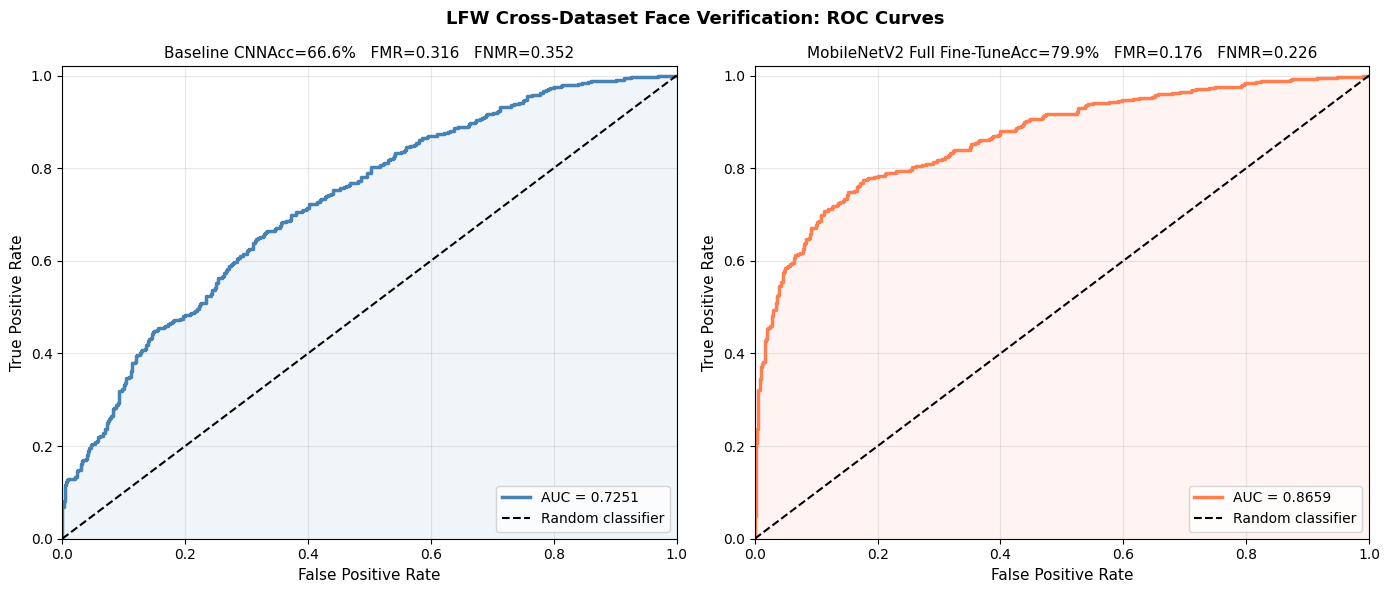

Saved: lfw_roc.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("LFW Cross-Dataset Face Verification: ROC Curves", fontsize=13, fontweight="bold")

for ax, res, name, col in zip(
    axes,
    [lfw_b, lfw_t],
    ["Baseline CNN", "MobileNetV2 Full Fine-Tune"],
    ["steelblue", "coral"]
):
    ax.plot(res["fpr"], res["tpr"], color=col, lw=2.5, label=f"AUC = {res['auc']:.4f}")
    ax.fill_between(res["fpr"], res["tpr"], alpha=0.08, color=col)
    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(
        f"{name}"
        f"Acc={res['accuracy']*100:.1f}%   "
        f"FMR={res['fmr']:.3f}   "
        f"FNMR={res['fnmr']:.3f}",
        fontsize=11
    )
    ax.legend(loc="lower right", fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lfw_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lfw_roc.png")

## 7.4 Cosine Similarity Distribution

Histogram of cosine similarity scores for matched vs mismatched pairs. Separation between distributions indicates embedding discriminability.

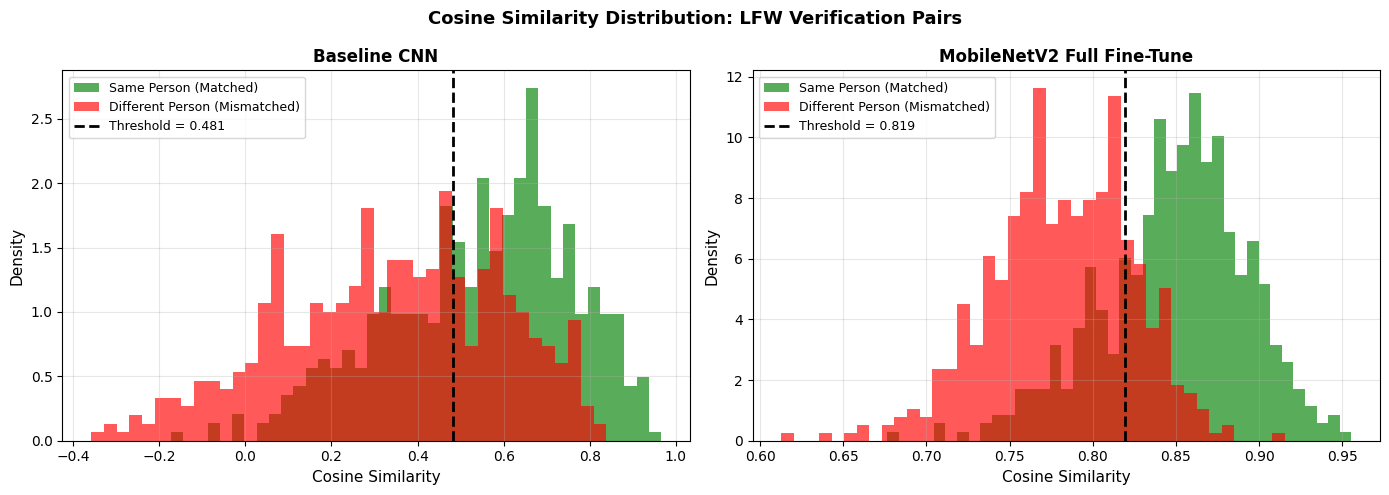

Saved: lfw_similarity_dist.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cosine Similarity Distribution: LFW Verification Pairs", fontsize=13, fontweight="bold")

for ax, res, name in zip(
    axes,
    [lfw_b, lfw_t],
    ["Baseline CNN", "MobileNetV2 Full Fine-Tune"]
):
    sims = res["similarities"]
    labs = res["labels"]

    ax.hist(sims[labs == 1], bins=40, alpha=0.65, color="green",
            label="Same Person (Matched)", density=True)
    ax.hist(sims[labs == 0], bins=40, alpha=0.65, color="red",
            label="Different Person (Mismatched)", density=True)
    ax.axvline(res["threshold"], color="black", linestyle="--", lw=2,
               label=f"Threshold = {res['threshold']:.3f}")

    ax.set_xlabel("Cosine Similarity", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lfw_similarity_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lfw_similarity_dist.png")

# 8. Deployment Analysis

Assess each model's suitability for real-world security deployment: parameter count, inference latency, and generalisation gap.

## 8.1 Parameter Count and Model Size

Compare total parameters and estimated storage sizes as proxies for memory requirements in edge deployment.

Model Parameter and Size Comparison
_____________________________________________
       Model  Total Params  Size (MB)
Baseline CNN        771593       3.09
 MobileNetV2       2969769      11.88


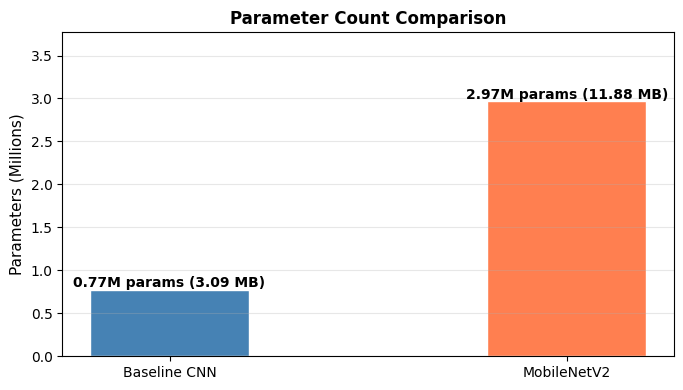

Saved: param_comparison.png


In [28]:
param_data = {
    "Model"       : ["Baseline CNN", "MobileNetV2"],
    "Total Params": [baseline_model.count_params(), tl_model.count_params()],
    "Size (MB)"   : [round(baseline_model.count_params() * 4 / 1e6, 2),
                     round(tl_model.count_params()       * 4 / 1e6, 2)]
}
param_df = pd.DataFrame(param_data)

print("Model Parameter and Size Comparison")
print("_" * 45)
print(param_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(param_df["Model"], param_df["Total Params"] / 1e6,
              color=["steelblue", "coral"], edgecolor="white", width=0.4)
for i, (bar, row) in enumerate(zip(bars, param_df.itertuples())):
    ax.text(i, row._2 / 1e6 + 0.03,
            f"{row._2/1e6:.2f}M params ({row._3} MB)",
            ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Parameters (Millions)", fontsize=11)
ax.set_title("Parameter Count Comparison", fontsize=12, fontweight="bold")
ax.set_ylim(0, param_df["Total Params"].max() / 1e6 + 0.8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("param_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: param_comparison.png")

## 8.2 Inference Latency

Mean inference time per single image measured over 100 forward passes after 5-pass GPU warmup.

2026-07-25 12:04:56.669046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 12:04:56.802975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Inference Latency (100-pass mean):
  Baseline CNN  : 77.97 ms per image
  MobileNetV2   : 82.09 ms per image
  Ratio         : 1.05x


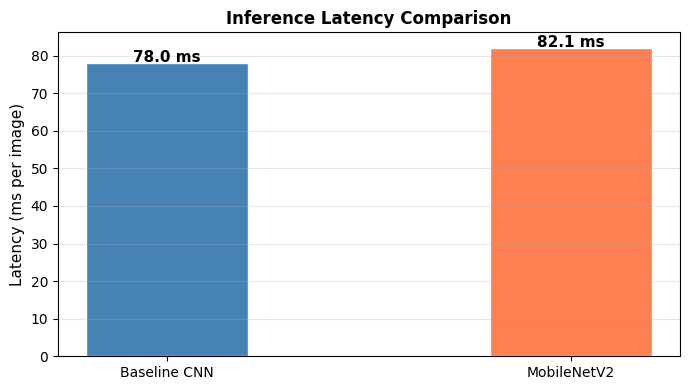

Saved: latency_comparison.png


In [29]:
dummy_input = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

# Warmup: 5 passes to fully initialise GPU execution pipeline
for _ in range(5):
    baseline_model.predict(dummy_input, verbose=0)
    tl_model.predict(dummy_input, verbose=0)

# Baseline CNN: measure 100 inference passes
start = time.time()
for _ in range(100):
    baseline_model.predict(dummy_input, verbose=0)
latency_b = (time.time() - start) / 100 * 1000   # convert to ms

# MobileNetV2: measure 100 inference passes
start = time.time()
for _ in range(100):
    tl_model.predict(dummy_input, verbose=0)
latency_t = (time.time() - start) / 100 * 1000

print(f"Inference Latency (100-pass mean):")
print(f"  Baseline CNN  : {latency_b:.2f} ms per image")
print(f"  MobileNetV2   : {latency_t:.2f} ms per image")
print(f"  Ratio         : {latency_t/latency_b:.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Baseline CNN", "MobileNetV2"], [latency_b, latency_t],
              color=["steelblue", "coral"], edgecolor="white", width=0.4)
for bar, v in zip(bars, [latency_b, latency_t]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{v:.1f} ms", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Latency (ms per image)", fontsize=11)
ax.set_title("Inference Latency Comparison", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: latency_comparison.png")

## 8.3 Generalisation Gap

Compare in-distribution Pins accuracy against cross-dataset LFW verification accuracy. The gap quantifies distributional robustness.

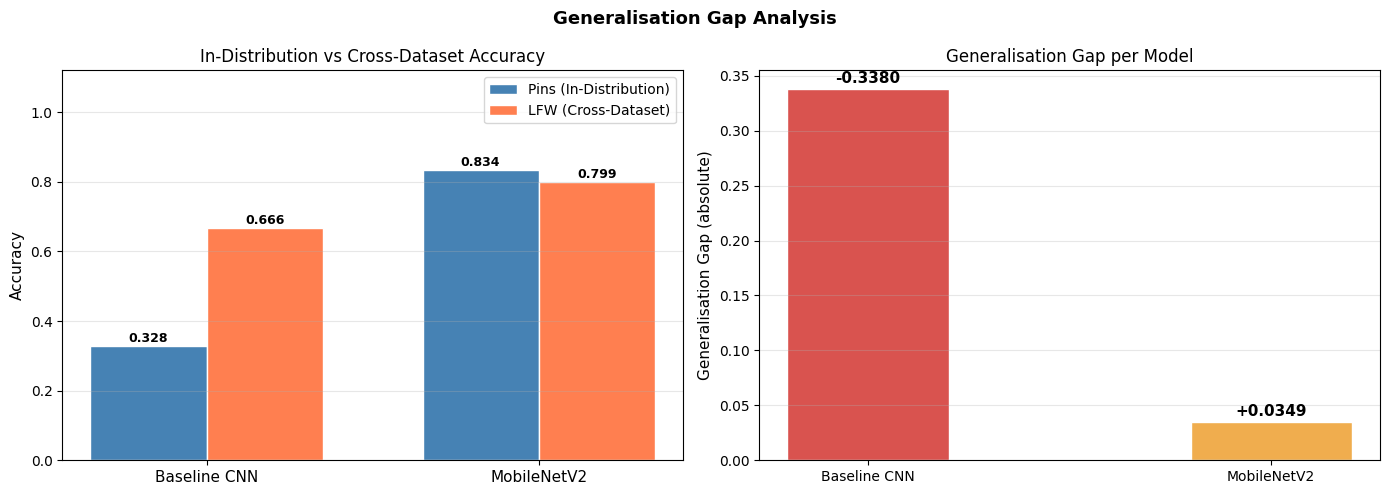

Generalisation Gap Summary:
---------------------------------------------
  Baseline CNN        : Pins=0.3280  LFW=0.6660  Gap=-0.3380
  MobileNetV2         : Pins=0.8339  LFW=0.7990  Gap=+0.0349


In [30]:
pins_accs   = [metrics_b["accuracy"], metrics_t["accuracy"]]
lfw_accs    = [lfw_b["accuracy"],      lfw_t["accuracy"]]
gaps        = [p - l for p, l in zip(pins_accs, lfw_accs)]
model_names = ["Baseline CNN", "MobileNetV2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Generalisation Gap Analysis", fontsize=13, fontweight="bold")

# Grouped bar: Pins vs LFW accuracy per model
x = np.arange(2); w = 0.35
bars_p = axes[0].bar(x - w/2, pins_accs, w, label="Pins (In-Distribution)",  color="steelblue", edgecolor="white")
bars_l = axes[0].bar(x + w/2, lfw_accs,  w, label="LFW (Cross-Dataset)",     color="coral",     edgecolor="white")

for i, (p, l) in enumerate(zip(pins_accs, lfw_accs)):
    axes[0].annotate(f"{p:.3f}", xy=(i - w/2, p + 0.012), ha="center", fontsize=9, fontweight="bold")
    axes[0].annotate(f"{l:.3f}", xy=(i + w/2, l + 0.012), ha="center", fontsize=9, fontweight="bold")

axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].set_ylim(0, 1.12); axes[0].set_ylabel("Accuracy", fontsize=11)
axes[0].set_title("In-Distribution vs Cross-Dataset Accuracy", fontsize=12)
axes[0].legend(fontsize=10); axes[0].grid(axis="y", alpha=0.3)

# Gap magnitude bar
gap_colours = ["#d9534f" if abs(g) > 0.15 else "#f0ad4e" for g in gaps]
bars_g = axes[1].bar(model_names, [abs(g) for g in gaps],
                     color=gap_colours, edgecolor="white", width=0.4)
for bar, g in zip(bars_g, gaps):
    axes[1].annotate(f"{g:+.4f}",
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005),
                     ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Generalisation Gap (absolute)", fontsize=11)
axes[1].set_title("Generalisation Gap per Model", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("generalisation_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Generalisation Gap Summary:")
print("-" * 45)
for m, g, p, l in zip(model_names, gaps, pins_accs, lfw_accs):
    print(f"  {m:<20}: Pins={p:.4f}  LFW={l:.4f}  Gap={g:+.4f}")

# 9. Final Results Summary

Consolidated results table for all models across all evaluation dimensions. Save models and all CSV outputs.

In [32]:
summary_df = pd.DataFrame({
    "Model"       : ["Baseline CNN", "MobileNetV2"],
    "Pins Acc"    : [metrics_b["accuracy"],  metrics_t["accuracy"]],
    "Pins F1"     : [metrics_b["f1"],        metrics_t["f1"]],
    "LFW Acc"     : [lfw_b["accuracy"],      lfw_t["accuracy"]],
    "LFW AUC"     : [lfw_b["auc"],           lfw_t["auc"]],
    "LFW F1"      : [lfw_b["f1"],            lfw_t["f1"]],
    "FMR"         : [lfw_b["fmr"],           lfw_t["fmr"]],
    "FNMR"        : [lfw_b["fnmr"],          lfw_t["fnmr"]],
    "Gen Gap"     : [metrics_b["accuracy"] - lfw_b["accuracy"],
                     metrics_t["accuracy"] - lfw_t["accuracy"]],
    "Parameters"  : [baseline_model.count_params(), tl_model.count_params()]
}).round(4)

print("FINAL DISSERTATION RESULTS")
print("_" * 80)
print(summary_df.to_string(index=False))

# Save all outputs
summary_df.to_csv("dissertation_final_results.csv",  index=False)
comparison_df.to_csv("pins_comparison.csv",          index=False)
per_class_df.to_csv("per_class_report.csv",          index=False)
param_df.to_csv("parameter_comparison.csv",          index=False)

baseline_model.save("baseline_cnn_final.keras")
tl_model.save("mobilenet_final.keras")

print("\nAll outputs saved:")
print("  dissertation_final_results.csv")
print("  pins_comparison.csv")
print("  per_class_report.csv")
print("  parameter_comparison.csv")
print("  baseline_cnn_final.keras")
print("  mobilenet_final.keras")
print("  All .png visualisations")

FINAL DISSERTATION RESULTS
________________________________________________________________________________
       Model  Pins Acc  Pins F1  LFW Acc  LFW AUC  LFW F1   FMR  FNMR  Gen Gap  Parameters
Baseline CNN    0.3280   0.3065    0.666   0.7251  0.6599 0.316 0.352  -0.3380      771593
 MobileNetV2    0.8339   0.8347    0.799   0.8659  0.7938 0.176 0.226   0.0349     2969769

All outputs saved:
  dissertation_final_results.csv
  pins_comparison.csv
  per_class_report.csv
  parameter_comparison.csv
  baseline_cnn_final.keras
  mobilenet_final.keras
  All .png visualisations


# 10. Ablation Studies

Controlled experiments measuring the contribution of individual components. All ablation models train at 96×96 resolution using isolated generators that do not affect the main 160×160 pipeline.

## 10.1 Augmentation Ablation Study

Three conditions trained under identical settings: no augmentation, horizontal flip only, and the full six-technique pipeline. Isolates the effect of augmentation on classification accuracy.

Training: No Augmentation
Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
  Best val accuracy: 0.0727 (7.27%)

Training: Flip Only
Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
  Best val accuracy: 0.0629 (6.29%)

Training: Full Pipeline
Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
  Best val accuracy: 0.0645 (6.45%)



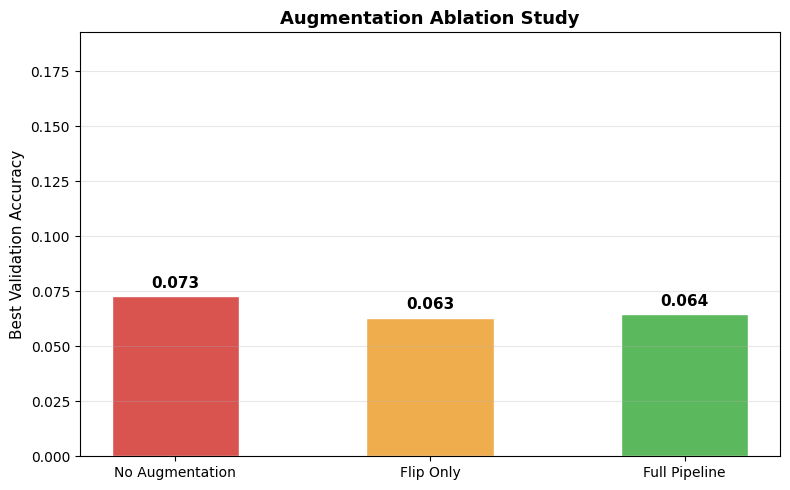

Augmentation Ablation Results:
  No Augmentation       : 0.0727 (7.27%)
  Flip Only             : 0.0629 (6.29%)
  Full Pipeline         : 0.0645 (6.45%)


In [33]:
ABLATION_IMG         = 96
ABLATION_STEPS_TRAIN = 200
ABLATION_STEPS_VAL   = 80

def build_small_cnn_ablation():
    model = models.Sequential([
        layers.Input(shape=(ABLATION_IMG, ABLATION_IMG, 3)),
        layers.Conv2D(32,(3,3),padding="same",activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(64,(3,3),padding="same",activation="relu"),
        layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.40), layers.Dense(NUM_CLASSES,activation="softmax")
    ], name="SmallCNN_Ablation")
    model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


aug_conditions = {
    "No Augmentation": ImageDataGenerator(rescale=1./255, validation_split=0.30),
    "Flip Only":       ImageDataGenerator(rescale=1./255, validation_split=0.30, horizontal_flip=True),
    "Full Pipeline":   ImageDataGenerator(rescale=1./255, validation_split=0.30,
                                          horizontal_flip=True, rotation_range=15,
                                          brightness_range=[0.7,1.3], zoom_range=0.15,
                                          width_shift_range=0.10, height_shift_range=0.10,
                                          fill_mode="nearest")
}
aug_ablation_results = {}

for condition_name, dgen in aug_conditions.items():
    print(f"Training: {condition_name}")
    tg = dgen.flow_from_directory(
        PINS_DIR, target_size=(ABLATION_IMG,ABLATION_IMG), batch_size=BATCH_SIZE,
        class_mode="categorical", subset="training", seed=SEED, shuffle=True
    )
    vg = ImageDataGenerator(rescale=1./255, validation_split=0.30).flow_from_directory(
        PINS_DIR, target_size=(ABLATION_IMG,ABLATION_IMG), batch_size=BATCH_SIZE,
        class_mode="categorical", subset="validation", seed=SEED, shuffle=False
    )
    m = build_small_cnn_ablation()
    h = m.fit(tg, epochs=15, steps_per_epoch=ABLATION_STEPS_TRAIN,
              validation_data=vg, validation_steps=ABLATION_STEPS_VAL, verbose=0,
              callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)])
    best_val = max(h.history["val_accuracy"])
    aug_ablation_results[condition_name] = best_val
    print(f"  Best val accuracy: {best_val:.4f} ({best_val*100:.2f}%)\n")

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(aug_ablation_results.keys(), aug_ablation_results.values(),
              color=["#d9534f","#f0ad4e","#5cb85c"], edgecolor="white", width=0.5)
for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004),
                ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Best Validation Accuracy", fontsize=11)
ax.set_title("Augmentation Ablation Study", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(aug_ablation_results.values())+0.12); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("aug_ablation.png", dpi=150, bbox_inches="tight"); plt.show()
print("Augmentation Ablation Results:")
for k, v in aug_ablation_results.items():
    print(f"  {k:<22}: {v:.4f} ({v*100:.2f}%)")

## 10.2 Architectural Ablation Study

Evaluate the contribution of batch normalisation and dropout by training variants of the baseline CNN with each component removed individually.

Found 12326 images belonging to 105 classes.
Found 5208 images belonging to 105 classes.
Training: Full Baseline  (771,593 params)


2026-07-25 12:22:46.460521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 12:22:46.602087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 12:23:46.555638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 12:23:46.693695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Best val accuracy: 0.0437 (4.37%)

Training: No Batch Norm  (767,625 params)
  Best val accuracy: 0.0277 (2.77%)

Training: No Dropout  (771,593 params)
  Best val accuracy: 0.3926 (39.26%)



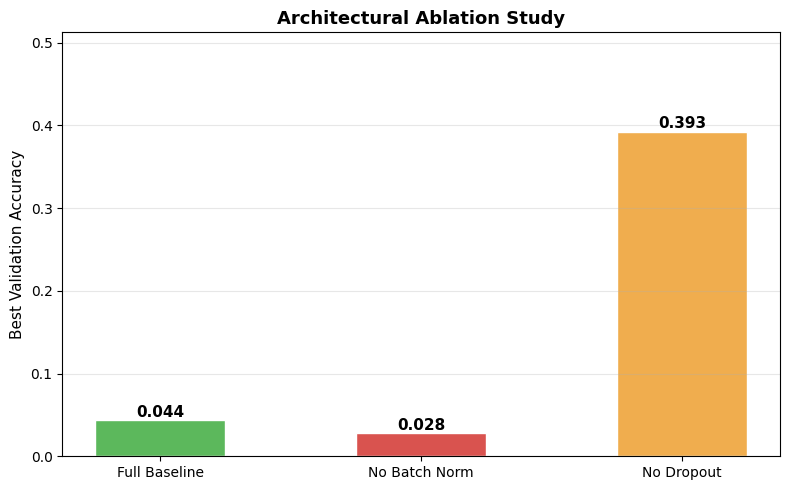

Architectural Ablation Results:
  Full Baseline         : 0.0437 (4.37%)
  No Batch Norm         : 0.0277 (2.77%)
  No Dropout            : 0.3926 (39.26%)


In [34]:
def build_cnn_no_batchnorm():
    model = models.Sequential(name="CNN_NoBatchNorm")
    model.add(layers.Input(shape=(ABLATION_IMG,ABLATION_IMG,3)))
    for f in [32,64,128]:
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.MaxPooling2D(2,2)); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
    model.add(layers.GlobalAveragePooling2D()); model.add(layers.Dropout(0.50))
    model.add(layers.Dense(512,activation="relu")); model.add(layers.Dropout(0.50))
    model.add(layers.Dense(NUM_CLASSES,activation="softmax"))
    return model

def build_cnn_no_dropout():
    model = models.Sequential(name="CNN_NoDropout")
    model.add(layers.Input(shape=(ABLATION_IMG,ABLATION_IMG,3)))
    for f in [32,64,128]:
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization()); model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512,activation="relu")); model.add(layers.BatchNormalization())
    model.add(layers.Dense(NUM_CLASSES,activation="softmax"))
    return model

def build_baseline_ablation():
    model = models.Sequential(name="CNN_Full")
    model.add(layers.Input(shape=(ABLATION_IMG,ABLATION_IMG,3)))
    for f in [32,64,128]:
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(f,(3,3),padding="same",activation="relu"))
        model.add(layers.MaxPooling2D(2,2)); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
    model.add(layers.BatchNormalization()); model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.50)); model.add(layers.Dense(512,activation="relu"))
    model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.50))
    model.add(layers.Dense(NUM_CLASSES,activation="softmax"))
    return model

ablation_tg = train_datagen.flow_from_directory(
    PINS_DIR, target_size=(ABLATION_IMG,ABLATION_IMG), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", seed=SEED, shuffle=True
)
ablation_vg = val_datagen.flow_from_directory(
    PINS_DIR, target_size=(ABLATION_IMG,ABLATION_IMG), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", seed=SEED, shuffle=False
)

arch_ablation_configs = {
    "Full Baseline": build_baseline_ablation(),
    "No Batch Norm": build_cnn_no_batchnorm(),
    "No Dropout":    build_cnn_no_dropout()
}
arch_ablation_results = {}

for variant_name, model in arch_ablation_configs.items():
    model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    print(f"Training: {variant_name}  ({model.count_params():,} params)")
    h = model.fit(ablation_tg, epochs=15, steps_per_epoch=ABLATION_STEPS_TRAIN,
                  validation_data=ablation_vg, validation_steps=ABLATION_STEPS_VAL, verbose=0,
                  callbacks=[callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)])
    best_val = max(h.history["val_accuracy"])
    arch_ablation_results[variant_name] = best_val
    print(f"  Best val accuracy: {best_val:.4f} ({best_val*100:.2f}%)\n")

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(arch_ablation_results.keys(), arch_ablation_results.values(),
              color=["#5cb85c","#d9534f","#f0ad4e"], edgecolor="white", width=0.5)
for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004),
                ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Best Validation Accuracy", fontsize=11)
ax.set_title("Architectural Ablation Study", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(arch_ablation_results.values())+0.12); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("arch_ablation.png", dpi=150, bbox_inches="tight"); plt.show()
print("Architectural Ablation Results:")
for k, v in arch_ablation_results.items():
    print(f"  {k:<22}: {v:.4f} ({v*100:.2f}%)")